In [1]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv()

# 모델 초기화
model = init_chat_model(
    "google_genai:gemini-3.1-flash-lite",
    temperature=0
)

In [2]:
from typing import TypedDict, Annotated
import operator

from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, AnyMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

# 2. State 정의
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

# 3. Node 정의
def llm_node(state: MessagesState):
    response = model.invoke(
        state["messages"]
    )
    return {"messages": [response]}

# 4. Graph 생성
graph_builder = StateGraph(MessagesState)

# 5. Graph에 Node 추가
graph_builder.add_node("llm", llm_node)

# 6. Edge 추가하여 Node 연결
graph_builder.add_edge(START, "llm")
graph_builder.add_edge("llm", END)

# 7. Graph를 실행 가능한 형태로 컴파일
checkpointer = InMemorySaver()
graph = graph_builder.compile(checkpointer=checkpointer)

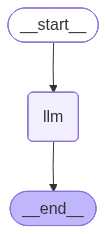

In [3]:
graph

In [4]:
config = {"configurable": {"thread_id": "conversation_1"}}

In [5]:
human_message = HumanMessage(content="내 이름은 김일남이야.")
initial_message = {"messages": [human_message]}
result = graph.invoke(initial_message, config=config)

In [6]:
result

{'messages': [HumanMessage(content='내 이름은 김일남이야.', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'type': 'text', 'text': '반갑습니다, 김일남 님! 만나서 정말 기뻐요. 오늘 하루는 어떻게 보내고 계신가요? 제가 도와드릴 일이 있다면 무엇이든 편하게 말씀해 주세요!', 'extras': {'signature': 'EjQKMgEMOdbHVhTQE8GHPN3+QoEmJ36diP2pDbgbGON7woT9lcjIakzgHs1KetQqW6FXaCmi'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ebfa0-1d98-7902-9b16-6ef8425ea1ac-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 41, 'total_tokens': 50, 'input_token_details': {'cache_read': 0}})]}

In [15]:
state_history = graph.get_state_history(config=config)

In [12]:
state_history

<generator object Pregel.get_state_history at 0x00000181C5B08720>

In [ ]:
for i, state in enumerate(state_history, start=1):
    print(f"--- State {i} ---")
    print(state)

--- State 1 ---
StateSnapshot(values={'messages': [HumanMessage(content='내 이름은 김일남이야.', additional_kwargs={}, response_metadata={}), AIMessage(content=[{'type': 'text', 'text': '반갑습니다, 김일남 님! 만나서 정말 기뻐요. 오늘 하루는 어떻게 보내고 계신가요? 제가 도와드릴 일이 있다면 무엇이든 편하게 말씀해 주세요!', 'extras': {'signature': 'EjQKMgEMOdbHVhTQE8GHPN3+QoEmJ36diP2pDbgbGON7woT9lcjIakzgHs1KetQqW6FXaCmi'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ebfa0-1d98-7902-9b16-6ef8425ea1ac-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 41, 'total_tokens': 50, 'input_token_details': {'cache_read': 0}})]}, next=(), config={'configurable': {'thread_id': 'conversation_1', 'checkpoint_ns': '', 'checkpoint_id': '1f166ef7-7854-61ec-8001-9f0d7d4ffb14'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-06-13T06:16:51.363479+00:00', parent_config={

In [16]:
result = list(state_history)

In [18]:
result[-1]

StateSnapshot(values={'messages': []}, next=('__start__',), config={'configurable': {'thread_id': 'conversation_1', 'checkpoint_ns': '', 'checkpoint_id': '1f166ef7-204e-6a61-bfff-b7f91046030c'}}, metadata={'source': 'input', 'step': -1, 'parents': {}}, created_at='2026-06-13T06:16:42.133769+00:00', parent_config=None, tasks=(PregelTask(id='4f9c4787-3287-1485-3448-1aaa899f8600', name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={'messages': [HumanMessage(content='내 이름은 김일남이야.', additional_kwargs={}, response_metadata={})]}),), interrupts=())

In [19]:
human_message = HumanMessage(content="대한민국에서 두번째로 큰 도시는 어디인가요?")
initial_message = {"messages": [human_message]}
graph.invoke(initial_message, config=config)

{'messages': [HumanMessage(content='내 이름은 김일남이야.', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'type': 'text', 'text': '반갑습니다, 김일남 님! 만나서 정말 기뻐요. 오늘 하루는 어떻게 보내고 계신가요? 제가 도와드릴 일이 있다면 무엇이든 편하게 말씀해 주세요!', 'extras': {'signature': 'EjQKMgEMOdbHVhTQE8GHPN3+QoEmJ36diP2pDbgbGON7woT9lcjIakzgHs1KetQqW6FXaCmi'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ebfa0-1d98-7902-9b16-6ef8425ea1ac-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 41, 'total_tokens': 50, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='대한민국에서 두번째로 큰 도시는 어디인가요?', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'type': 'text', 'text': '대한민국에서 두 번째로 큰 도시는 **부산광역시**입니다. \n\n참고로, 인구수와 경제 규모 면에서 서울특별시가 1위, 부산광역시가 2위를 차지하고 있습니다.', 'extras': {'signature': 'EjQKMgEMOdbHYcV1ja1F/Pejm/6P8rHj7IDAUu8

In [20]:
# 컨텍스트 엔지니어링: AI 실행 없이 수동으로 대화 기록(State)에 새 메시지를 주입하여 문맥을 조작함. 다음 상황에서 유용함.
# - 사용자 개입 (Human-in-the-loop)
# - 과거로 돌아가서 수정 (Time Travel)
# - 시스템 차원의 정보 주입
graph.update_state(
    config=config,
    values={"messages": [HumanMessage(content="그 도시의 관광명소를 알려주세요.")]},
)

result = graph.invoke({"messages": []}, config=config)
print(result["messages"][-1].content)

[{'type': 'text', 'text': "부산은 바다와 산, 그리고 도심의 매력이 어우러진 도시라 가볼 만한 곳이 정말 많습니다. 대표적인 관광 명소들을 몇 가지 추천해 드릴게요!\n\n**1. 해운대 & 광안리 (바다와 야경)**\n*   **해운대 해수욕장:** 부산의 상징과도 같은 곳이죠. 해변을 따라 걷거나 '해운대 블루라인파크'에서 해변 열차를 타보는 것을 추천합니다.\n*   **광안리 해수욕장:** 밤이 되면 광안대교의 화려한 야경을 볼 수 있습니다. 카페 거리에서 커피 한잔하며 야경을 즐기기 아주 좋습니다.\n\n**2. 감천문화마을 (이색적인 풍경)**\n*   '한국의 마추픽추'라고 불리는 곳입니다. 알록달록한 집들이 계단식으로 모여 있어 사진 찍기 좋고, 골목골목 숨겨진 예술 작품들을 구경하는 재미가 있습니다.\n\n**3. 해동용궁사 (바다 위의 절)**\n*   보통 절은 산속에 있지만, 이곳은 바닷가 바로 옆에 위치해 있어 파도 소리를 들으며 참배할 수 있는 아주 특별한 사찰입니다. 경치가 정말 아름답습니다.\n\n**4. 자갈치시장 & 국제시장 (먹거리와 활기)**\n*   **자갈치시장:** 부산의 활기찬 에너지를 느낄 수 있는 곳으로, 신선한 해산물을 맛볼 수 있습니다.\n*   **국제시장 & 깡통시장:** 씨앗호떡, 비빔당면 등 부산의 유명한 길거리 음식을 맛보기에 최적의 장소입니다.\n\n**5. 태종대 (자연 경관)**\n*   깎아지른 듯한 해안 절벽과 푸른 바다가 어우러진 절경을 볼 수 있습니다. 다누비 열차를 타고 편하게 둘러볼 수 있어요.\n\n**6. 흰여울문화마을 (영도)**\n*   바다 바로 옆 절벽 위에 자리 잡은 아기자기한 마을입니다. 영화 '변호인' 촬영지로도 유명하며, 바다를 보며 산책하기 정말 좋습니다.\n\n김일남 님은 혹시 바다를 좋아하시나요, 아니면 맛집 탐방을 더 좋아하시나요? 취향을 알려주시면 더 구체적으로 추천해 드릴 수 있습니다!", 'extras': {'signature': 'E

In [21]:
result

{'messages': [HumanMessage(content='내 이름은 김일남이야.', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'type': 'text', 'text': '반갑습니다, 김일남 님! 만나서 정말 기뻐요. 오늘 하루는 어떻게 보내고 계신가요? 제가 도와드릴 일이 있다면 무엇이든 편하게 말씀해 주세요!', 'extras': {'signature': 'EjQKMgEMOdbHVhTQE8GHPN3+QoEmJ36diP2pDbgbGON7woT9lcjIakzgHs1KetQqW6FXaCmi'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ebfa0-1d98-7902-9b16-6ef8425ea1ac-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 41, 'total_tokens': 50, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='대한민국에서 두번째로 큰 도시는 어디인가요?', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'type': 'text', 'text': '대한민국에서 두 번째로 큰 도시는 **부산광역시**입니다. \n\n참고로, 인구수와 경제 규모 면에서 서울특별시가 1위, 부산광역시가 2위를 차지하고 있습니다.', 'extras': {'signature': 'EjQKMgEMOdbHYcV1ja1F/Pejm/6P8rHj7IDAUu8